In [1]:
from module import *

# Info

In [2]:
table_info("hourly_calories")

nrows: 24084
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            5 non-null      float64
 1   ActivityHour  5 non-null      str    
 2   Calories      5 non-null      int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 252.0 bytes


,Id,ActivityHour,Calories
0,1.503960e+09,3/12/2016 12:00:00 AM,48
1,1.503960e+09,3/12/2016 1:00:00 AM,48
2,1.503960e+09,3/12/2016 2:00:00 AM,48
3,1.503960e+09,3/12/2016 3:00:00 AM,48
4,1.503960e+09,3/12/2016 4:00:00 AM,48


In [3]:
table_info("hourly_intensity")

nrows: 24084
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                5 non-null      float64
 1   ActivityHour      5 non-null      str    
 2   TotalIntensity    5 non-null      int64  
 3   AverageIntensity  5 non-null      float64
dtypes: float64(2), int64(1), str(1)
memory usage: 292.0 bytes


,Id,ActivityHour,TotalIntensity,AverageIntensity
0,1.503960e+09,3/12/2016 12:00:00 AM,0,0.0
1,1.503960e+09,3/12/2016 1:00:00 AM,0,0.0
2,1.503960e+09,3/12/2016 2:00:00 AM,0,0.0
3,1.503960e+09,3/12/2016 3:00:00 AM,0,0.0
4,1.503960e+09,3/12/2016 4:00:00 AM,0,0.0


In [2]:
table_info("hourly_steps")

nrows: 24084
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            5 non-null      float64
 1   ActivityHour  5 non-null      str    
 2   StepTotal     5 non-null      int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 252.0 bytes


,Id,ActivityHour,StepTotal
0,1.503960e+09,3/12/2016 12:00:00 AM,0
1,1.503960e+09,3/12/2016 1:00:00 AM,0
2,1.503960e+09,3/12/2016 2:00:00 AM,0
3,1.503960e+09,3/12/2016 3:00:00 AM,0
4,1.503960e+09,3/12/2016 4:00:00 AM,0


# Data

In [2]:
df = pd.read_sql("""
                 SELECT *
                 FROM hourly_calories
                 NATURAL JOIN hourly_intensity
                 NATURAL JOIN hourly_steps
                 """, conn)
df['Id'] = df['Id'].astype(int)
df['ActivityHour'] = pd.to_datetime(df['ActivityHour'], format=DATE_FMT)
df

,Id,ActivityHour,Calories,TotalIntensity,AverageIntensity,StepTotal
0,1503960366,2016-03-12 00:00:00,48,0,0.000000,0
1,1503960366,2016-03-12 01:00:00,48,0,0.000000,0
2,1503960366,2016-03-12 02:00:00,48,0,0.000000,0
3,1503960366,2016-03-12 03:00:00,48,0,0.000000,0
4,1503960366,2016-03-12 04:00:00,48,0,0.000000,0
...,...,...,...,...,...,...
24079,8877689391,2016-04-12 04:00:00,73,0,0.000000,0
24080,8877689391,2016-04-12 05:00:00,73,0,0.000000,0
24081,8877689391,2016-04-12 06:00:00,96,7,0.116667,209
24082,8877689391,2016-04-12 07:00:00,169,26,0.433333,964


# Means

In [48]:
means = df.drop(columns='Id').groupby('ActivityHour').mean()
means

,Calories,TotalIntensity,AverageIntensity,StepTotal
ActivityHour,,,,
2016-03-12 00:00:00,72.757576,2.969697,0.049495,37.000000
2016-03-12 01:00:00,69.818182,1.424242,0.023737,22.000000
2016-03-12 02:00:00,69.333333,0.878788,0.014646,12.393939
2016-03-12 03:00:00,68.000000,0.515152,0.008586,4.393939
2016-03-12 04:00:00,67.909091,0.484848,0.008081,5.636364
...,...,...,...,...
2016-04-12 06:00:00,77.529412,5.647059,0.094118,127.705882
2016-04-12 07:00:00,116.800000,22.266667,0.371111,684.533333
2016-04-12 08:00:00,94.833333,11.000000,0.183333,307.333333


## Plots

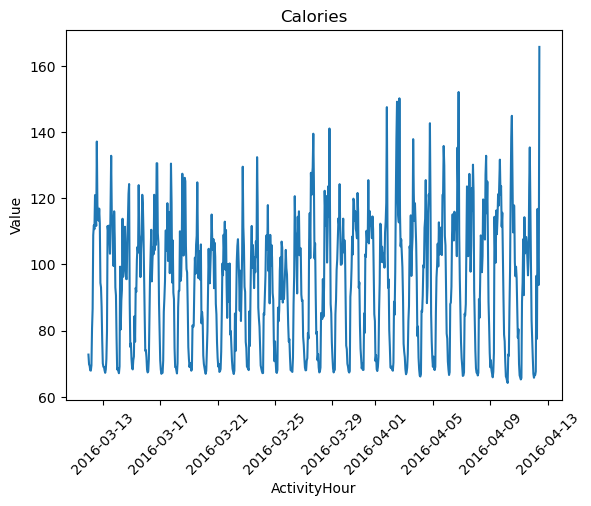

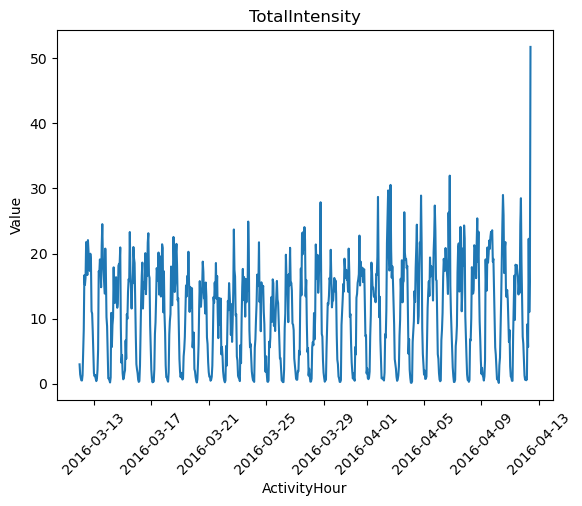

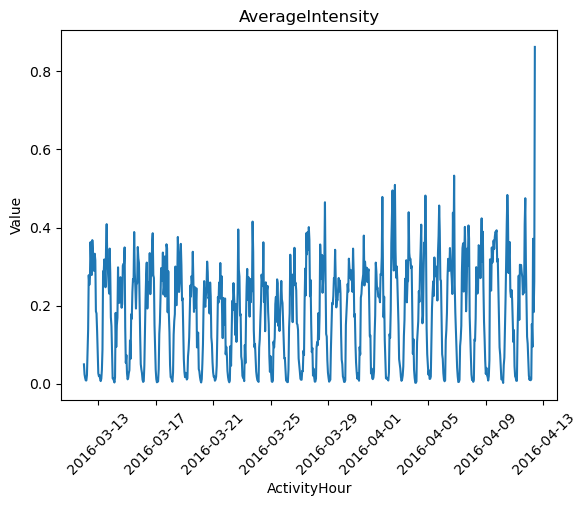

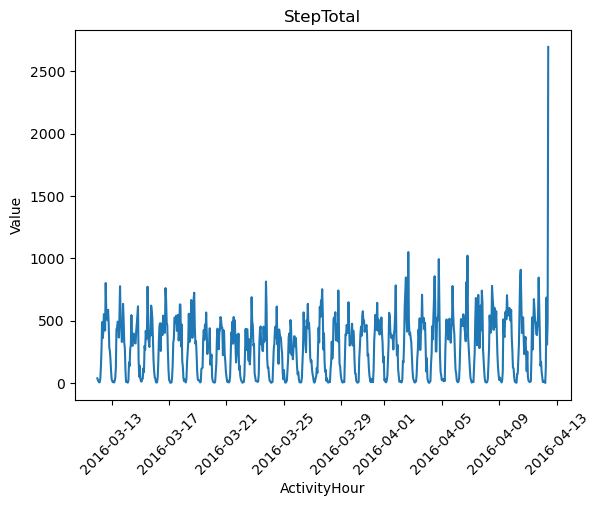

In [49]:
for var in means:
    ax = sns.lineplot(means[var])
    ax.set_title(f"{var}")
    ax.set_ylabel('Value')
    plt.xticks(rotation=45)
    plt.show()

## OLS

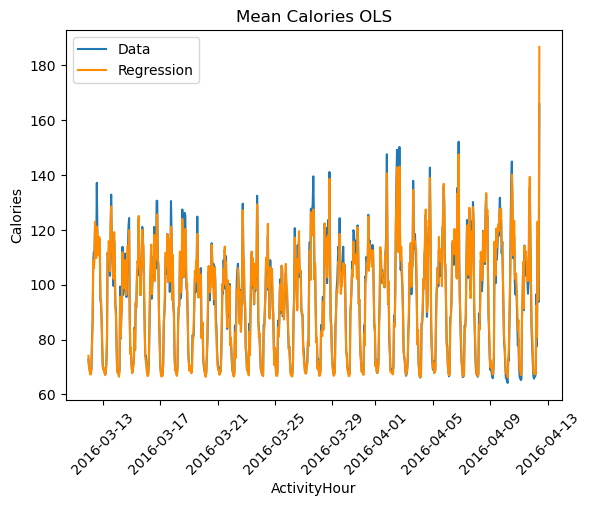

                            OLS Regression Results                            
Dep. Variable:               Calories   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                 1.717e+04
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:11:23   Log-Likelihood:                -1869.6
No. Observations:                 755   AIC:                             3745.
Df Residuals:                     752   BIC:                             3759.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             65.9116      0.195    338.

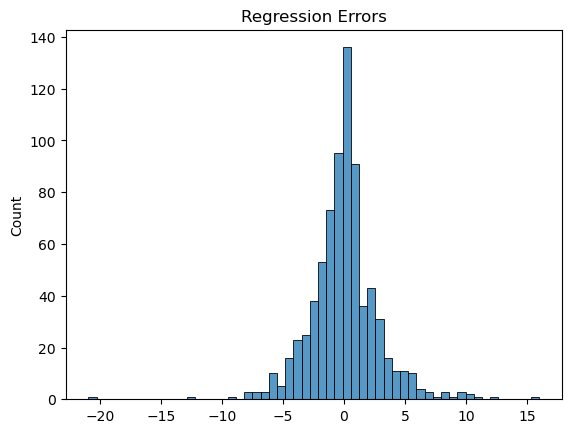

In [50]:
y = means['Calories']
X = means[['TotalIntensity', 'StepTotal']]
X = sm.add_constant(X)
plot_linear_regression(X, y, "Mean Calories OLS")

## STL

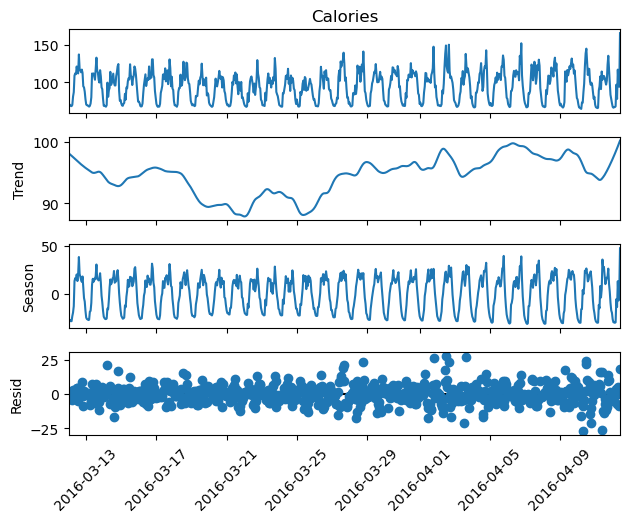

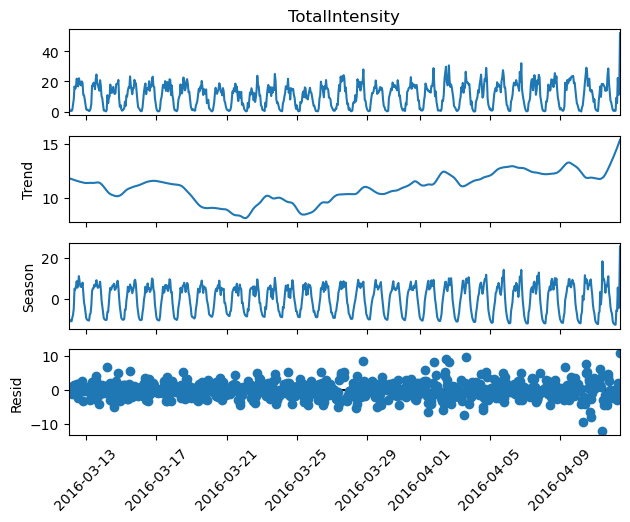

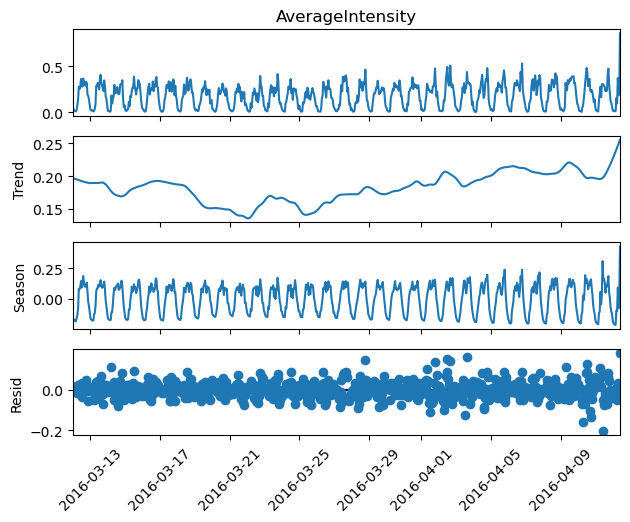

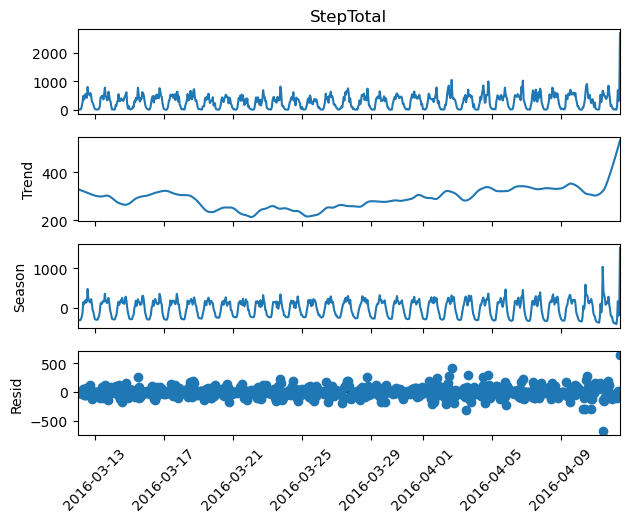

In [51]:
for var in means:
    stl = STL(means[var], period=24)
    res = stl.fit()
    fig = res.plot()
    plt.xticks(rotation=45)
    plt.show()

# Quantiles

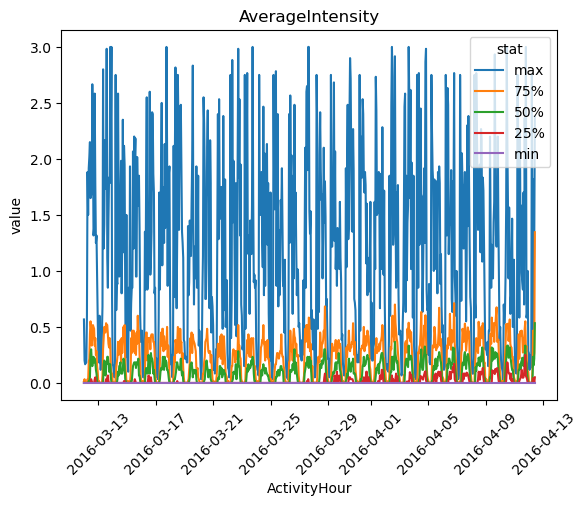

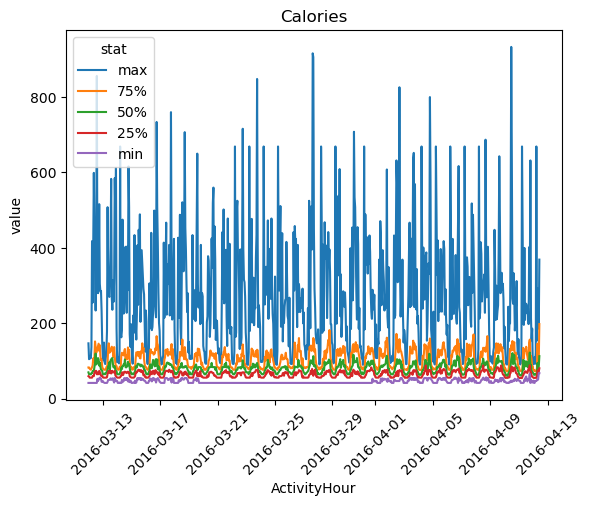

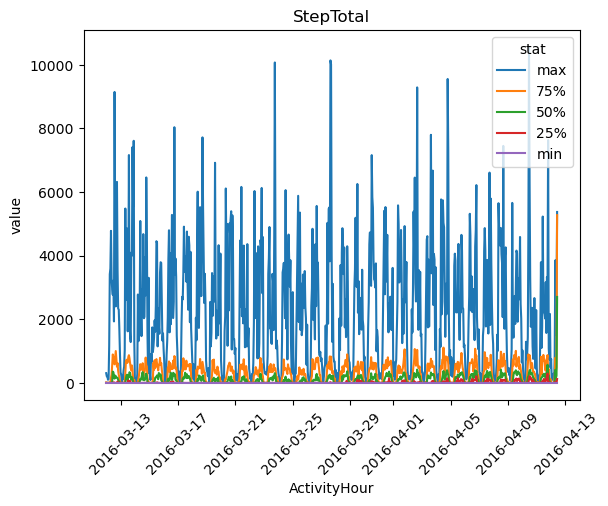

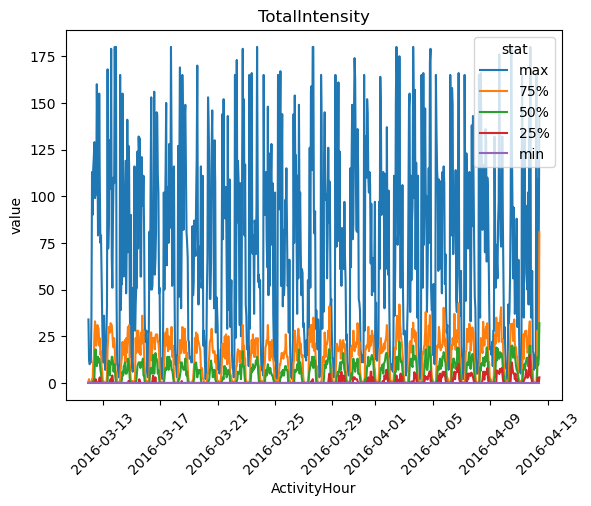

In [60]:
melt = df.melt(
    id_vars=['Id','ActivityHour'],
    value_vars=['Calories', 'TotalIntensity', 'AverageIntensity', 'StepTotal']
)
stats = melt.groupby(['variable','ActivityHour'])['value'].describe().reset_index()
stats_melt = stats.melt(
                id_vars=['variable','ActivityHour'],
                value_vars=['min','25%','50%','75%','max'][::-1],
                var_name='stat',
                value_name='value'
)
for var in stats_melt['variable'].unique():
    var_df = stats_melt[stats_melt['variable'] == var]
    sns.lineplot(var_df, x='ActivityHour', y='value', hue='stat')
    plt.title(f"{var}")
    plt.xticks(rotation=45)
    plt.show()